In [1]:
# 패키지 로드
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import IsolationForest
import polars as pl
import plotly.graph_objects as go
import shap

c:\Users\cromi\Documents\core\SOTA\Project05\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 데이터 로드
data = load_breast_cancer()
X, _ = data.data, data.target   # 비지도 학습이므로 y는 버린다
schema = list(data.feature_names)

In [3]:
# 기초통계량 출력
df = pl.DataFrame(X, schema=schema)
df.describe()

statistic,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",14.127292,19.289649,91.969033,654.889104,0.09636,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.26919,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
"""std""",3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.07972,0.038803,0.027414,0.00706,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.00617,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
"""min""",6.981,9.71,43.79,143.5,0.05263,0.01938,0.0,0.0,0.106,0.04996,0.1115,0.3602,0.757,6.802,0.001713,0.002252,0.0,0.0,0.007882,0.0008948,7.93,12.02,50.41,185.2,0.07117,0.02729,0.0,0.0,0.1565,0.05504
"""25%""",11.7,16.17,75.17,420.3,0.08637,0.06492,0.02956,0.02031,0.1619,0.0577,0.2324,0.8339,1.606,17.85,0.005169,0.01308,0.01509,0.007638,0.01516,0.002248,13.01,21.08,84.11,515.3,0.1166,0.1472,0.1145,0.06493,0.2504,0.07146
"""50%""",13.37,18.84,86.24,551.1,0.09587,0.09263,0.06154,0.0335,0.1792,0.06154,0.3242,1.108,2.287,24.53,0.00638,0.02045,0.02589,0.01093,0.01873,0.003187,14.97,25.41,97.66,686.5,0.1313,0.2119,0.2267,0.09993,0.2822,0.08004
"""75%""",15.78,21.8,104.1,782.7,0.1053,0.1304,0.1307,0.074,0.1957,0.06612,0.4789,1.474,3.357,45.19,0.008146,0.03245,0.04205,0.01471,0.02348,0.004558,18.79,29.72,125.4,1084.0,0.146,0.3391,0.3829,0.1614,0.3179,0.09208
"""max""",28.11,39.28,188.5,2501.0,0.1634,0.3454,0.4268,0.2012,0.304,0.09744,2.873,4.885,21.98,542.2,0.03113,0.1354,0.396,0.05279,0.07895,0.02984,36.04,49.54,251.2,4254.0,0.2226,1.058,1.252,0.291,0.6638,0.2075


In [4]:
# 모델 학습
model = IsolationForest(n_jobs=-1, random_state=42)
model.fit(df)
model.predict(df)   # 이상치는 -1로 출력

array([-1,  1,  1, -1,  1,  1,  1,  1,  1, -1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1, -1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1, -1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,
        1,  1,  1,  1,  1,  1, -1,  1,  1,  1, -1,  1,  1,  1, -1,  1,  1,
        1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1, -1,  1,  1,  1, -1, -1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1, -1, -1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

In [5]:
model.score_samples(df)
# -0.5를 기준으로 이보다 더 작은 값은 이상치로 판별

array([-0.56031992, -0.43488577, -0.43704173, -0.63237602, -0.44336105,
       -0.44250518, -0.40691484, -0.42063389, -0.44337118, -0.5685877 ,
       -0.40361504, -0.40127673, -0.61063777, -0.4040406 , -0.49620999,
       -0.45013455, -0.38657437, -0.43697043, -0.46433913, -0.36992434,
       -0.37619105, -0.4134131 , -0.46574887, -0.47783138, -0.45323722,
       -0.5257707 , -0.44666923, -0.43147133, -0.42686012, -0.40277577,
       -0.43711282, -0.46365508, -0.43570356, -0.44539625, -0.42906154,
       -0.41197227, -0.39258009, -0.39657941, -0.50250098, -0.39076954,
       -0.3752676 , -0.4305897 , -0.5642146 , -0.38929486, -0.41270694,
       -0.45469039, -0.45781608, -0.41250532, -0.37288188, -0.36488377,
       -0.37237215, -0.36963101, -0.36568212, -0.44018813, -0.38311387,
       -0.37222017, -0.41620974, -0.39101483, -0.41073832, -0.44704269,
       -0.45803091, -0.45594329, -0.46617384, -0.45367948, -0.40671646,
       -0.38537577, -0.40591605, -0.36917649, -0.57790814, -0.37

In [6]:
# SHAP 값 산출
explainer = shap.Explainer(model)
shap_values = explainer(X)

expected_value = explainer.expected_value
sv = shap_values.values
shap_values.feature_names = schema

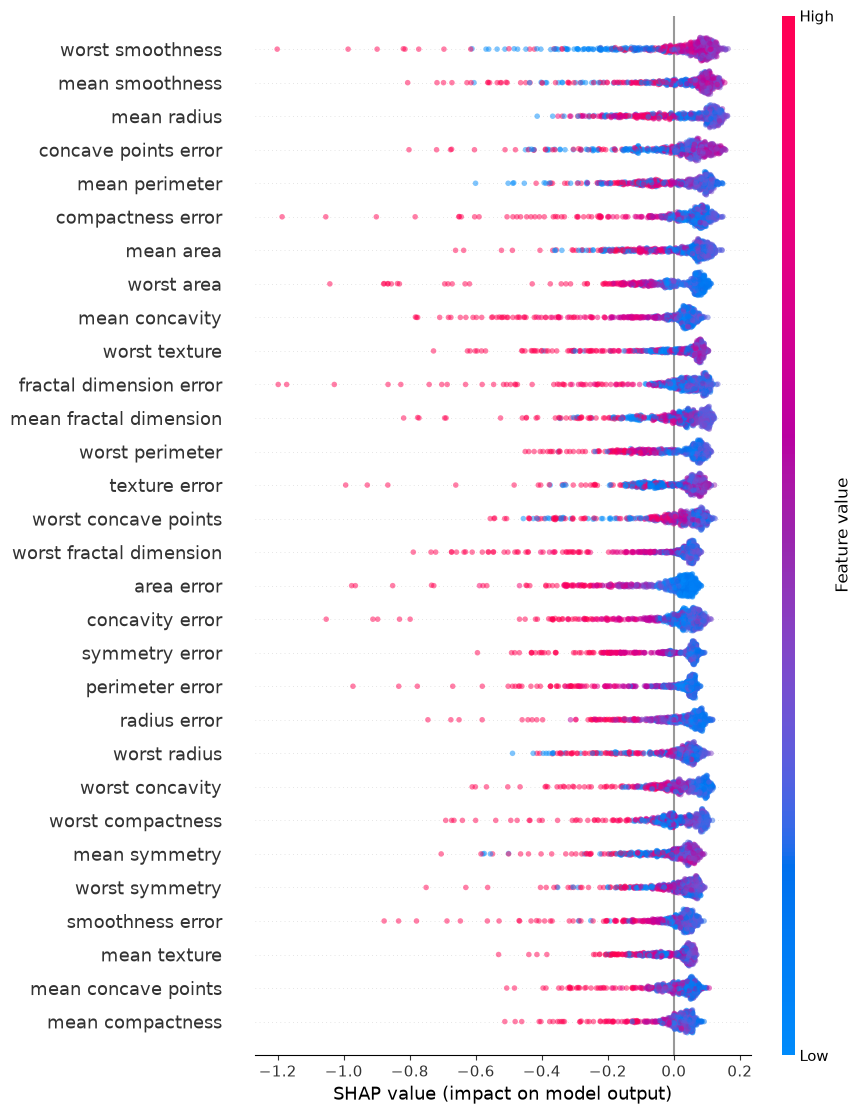

In [7]:
# 전역적 SHAP 값
shap.plots.beeswarm(shap_values, max_display=30, alpha=0.5)

# 대체로 높은 feature값은 이상치로 판별하는 것으로 보인다 

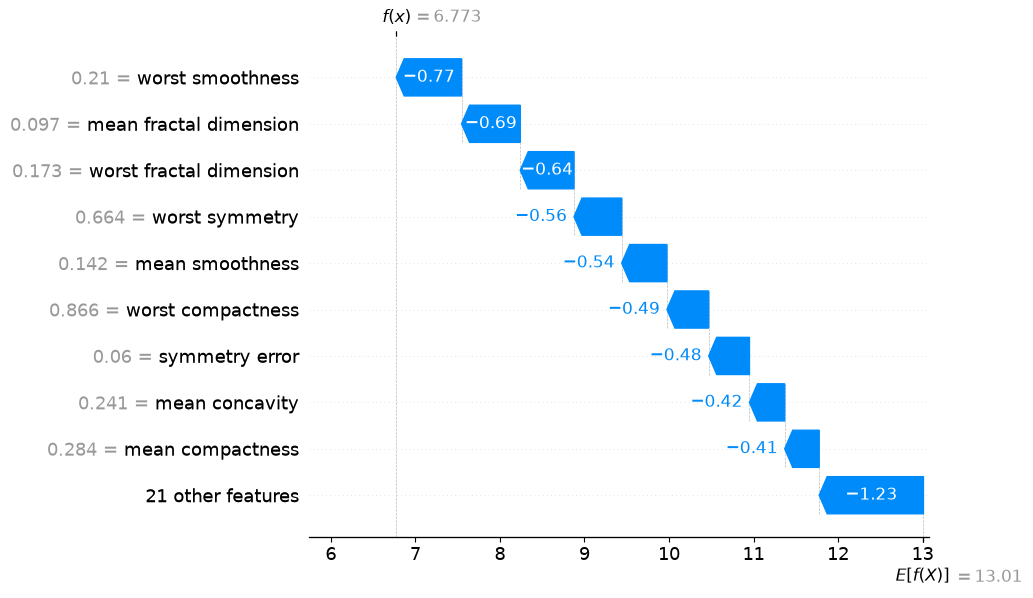

In [8]:
# 샘플별 SHAP 값
shap.plots.waterfall(shap_values[3])    # 이상치의 경우(score:-0.63237602)

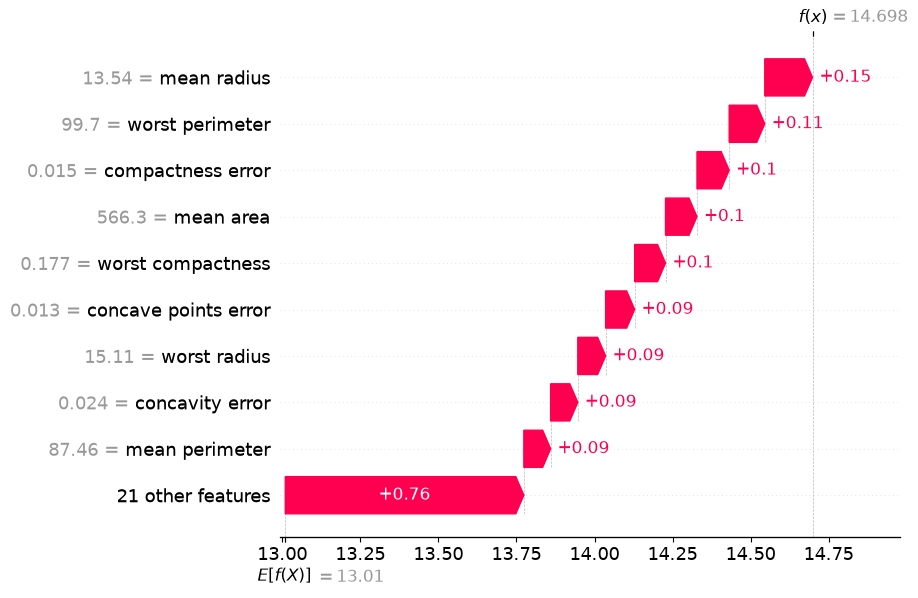

In [9]:
shap.plots.waterfall(shap_values[19])   # 정상치의 경우(score: -0.36992434)

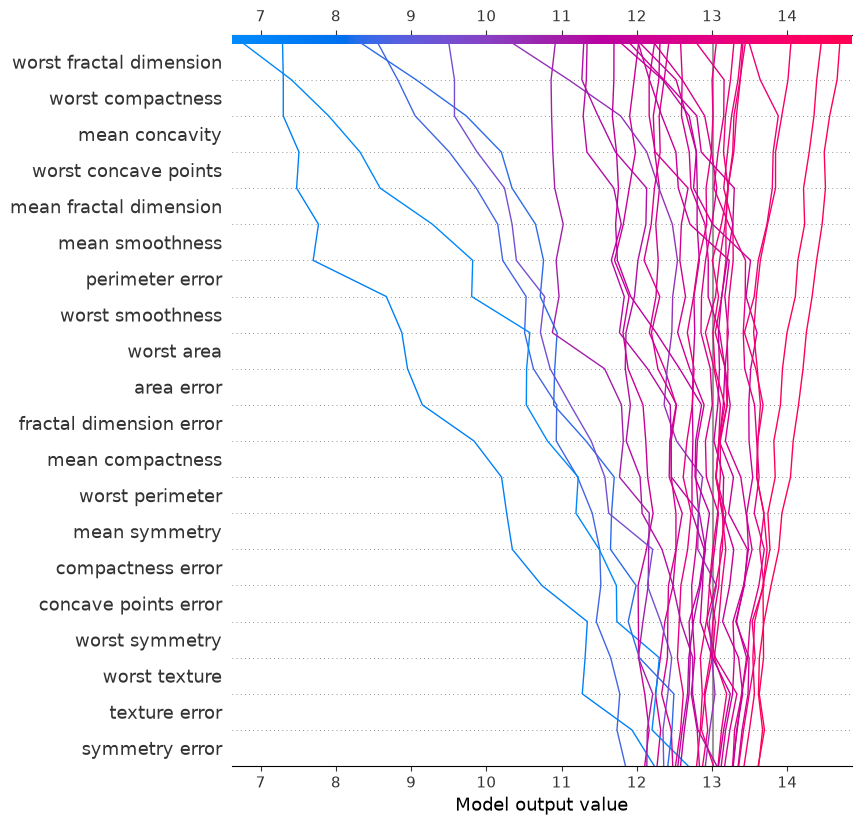

In [10]:
# 국소적 샘플 행동양상
shap.decision_plot(expected_value, shap_values.values[:30], schema)

In [11]:
# 각 특성 SHAP값을 열의 합으로 산출
sv_result = sv.sum(axis=1)

In [12]:
# 기존 데이터프레임과 병합
sv_df = df.with_columns(shap_values=sv_result)
sv_df

mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,shap_values
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,1.095,0.9053,8.589,153.4,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,-4.448181
20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.0186,0.0134,0.01389,0.003532,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.186,0.275,0.08902,-0.702547
19.69,21.25,130.0,1203.0,0.1096,0.1599,0.1974,0.1279,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.00615,0.04006,0.03832,0.02058,0.0225,0.004571,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.243,0.3613,0.08758,-0.775638
11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,0.2597,0.09744,0.4956,1.156,3.445,27.23,0.00911,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.5,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.173,-6.23622
20.29,14.34,135.1,1297.0,0.1003,0.1328,0.198,0.1043,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.01149,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.2,1575.0,0.1374,0.205,0.4,0.1625,0.2364,0.07678,-0.987818
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
21.56,22.39,142.0,1479.0,0.111,0.1159,0.2439,0.1389,0.1726,0.05623,1.176,1.256,7.673,158.7,0.0103,0.02891,0.05198,0.02454,0.01114,0.004239,25.45,26.4,166.1,2027.0,0.141,0.2113,0.4107,0.2216,0.206,0.07115,-2.732565
20.13,28.25,131.2,1261.0,0.0978,0.1034,0.144,0.09791,0.1752,0.05533,0.7655,2.463,5.203,99.04,0.005769,0.02423,0.0395,0.01678,0.01898,0.002498,23.69,38.25,155.0,1731.0,0.1166,0.1922,0.3215,0.1628,0.2572,0.06637,-1.320337
16.6,28.08,108.3,858.1,0.08455,0.1023,0.09251,0.05302,0.159,0.05648,0.4564,1.075,3.425,48.55,0.005903,0.03731,0.0473,0.01557,0.01318,0.003892,18.98,34.12,126.7,1124.0,0.1139,0.3094,0.3403,0.1418,0.2218,0.0782,-0.042116


In [ ]:
# 동적 시각화 도구 plotly 사용
fig = go.Figure()

# 처음에는 첫 번째 feature를 표시
first_col = sv_df.columns[0]

fig.add_trace(
    go.Scatter(
        x=sv_df[first_col].to_list(),
        y=sv_df['shap_values'].to_list(),
        mode="markers",
        name="data"
    )
)

# Dropdown 메뉴
buttons = []

for col in sv_df.columns:
    buttons.append(
        dict(
            label=col,
            method="update",
            args=[
                {"x": [sv_df[col].to_list()]},       # x 데이터 변경
                {"title": f"{col} vs shap values",
                 "xaxis": {"title": col}}
            ]
        )
    )

fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=0.0,
            y=1.15
        )
    ],
    title=f"{first_col} vs shap values",
    xaxis_title=first_col,
    yaxis_title="shap values"
)

fig.show()

In [ ]:
'''
인사이트 :
대체로 많은 특성이 반비례 관계를 가지는 것으로 보임
어떤 특성은 좌측으로 쏠린 봉우리처럼 너무 낮아도 이상치라 판별하기도 함
상관관계의 신뢰도는 그리 높지 않아 보임

문제점 :
데이터 > 569개의 샘플은 상당히 작은 편
특성의 상호작용 > 피어슨 상관분석 필요
모델 > 샘플링을 달리하는 등 교차검증 필요
shap > 이상치의 경우 특성의 상호작용으로 다른 특성 또한 낮은 행동을 보임

코드로 배운것 :
uv 패키지 설치는 매우 빠르고 쉽다, 특히 가상환경에 파이썬을 따로 설치할 필요가 없다
polars를 지원하지 않는 패키지가 있어 보완하는 코드가 필요했다
plotly의 동적 시각화는 특성이 많은 이 데이터셋과 잘 어울린다
shap의 파생 패키지도 다뤄볼만하다
'''